In [169]:
# importing Important libaries:
import numpy as numpy 
import pandas as pd 
import pickle as pkl
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn import metrics 
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.cluster import KMeans 
import warnings
warnings.filterwarnings('ignore')



In [85]:
# Importing the Dataset:
df = pd.read_csv("C:/guvi/project_4/single_genre_artists.csv")
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [86]:
df.shape

(95837, 23)

In [87]:
# There are 95837 rows and 23 columns are available in the dataset

In [88]:
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

In [89]:
# As we can 23 column names are in lower case format we need to change capitalize format 

In [90]:
# getting an idea about the data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [91]:
# Release date is in str format , so that we need to change those data type and all str datatype convert into object Datatype 
# here we can identify non null count values as well 
# There in no null values 

In [92]:
# Modifying columns names are title format :
df.columns = df.columns.str.title().str.strip()
df.columns

Index(['Id_Songs', 'Name_Song', 'Popularity_Songs', 'Duration_Ms', 'Explicit',
       'Id_Artists', 'Release_Date', 'Danceability', 'Energy', 'Key',
       'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Time_Signature', 'Followers', 'Genres',
       'Name_Artists', 'Popularity_Artists'],
      dtype='object')

In [93]:
# correct Datatypes in incorrect datatypes:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], format = 'mixed') 
df[['Id_Songs', 'Name_Song', 'Id_Artists', 'Genres', 'Name_Artists']] = df[['Id_Songs', 'Name_Song', 'Id_Artists', 'Genres', 'Name_Artists']].astype('object')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Id_Songs            95837 non-null  object        
 1   Name_Song           95837 non-null  object        
 2   Popularity_Songs    95837 non-null  int64         
 3   Duration_Ms         95837 non-null  int64         
 4   Explicit            95837 non-null  int64         
 5   Id_Artists          95837 non-null  object        
 6   Release_Date        95837 non-null  datetime64[ns]
 7   Danceability        95837 non-null  float64       
 8   Energy              95837 non-null  float64       
 9   Key                 95837 non-null  int64         
 10  Loudness            95837 non-null  float64       
 11  Mode                95837 non-null  int64         
 12  Speechiness         95837 non-null  float64       
 13  Acousticness        95837 non-null  float64   

In [94]:
# Getting an idea about Null values :
df.isnull().sum().any()

np.False_

In [95]:
'np.False means there is no null values present in the data'

'np.False means there is no null values present in the data'

In [96]:
# Getting an idea about duplicate values: 
df.duplicated().sum()

np.int64(0)

In [97]:
"np.int64(0) means there is no duplicates"

'np.int64(0) means there is no duplicates'

In [98]:
df.columns

Index(['Id_Songs', 'Name_Song', 'Popularity_Songs', 'Duration_Ms', 'Explicit',
       'Id_Artists', 'Release_Date', 'Danceability', 'Energy', 'Key',
       'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness',
       'Liveness', 'Valence', 'Tempo', 'Time_Signature', 'Followers', 'Genres',
       'Name_Artists', 'Popularity_Artists'],
      dtype='object')

In [99]:
# Drop unnecessary columns :
# Remove track_name, artist_name, and track_id as they are not needed for clustering.
df.drop(['Name_Artists', 'Id_Songs','Name_Song'], axis = 1,inplace = True) 
df.shape

(95837, 20)

In [100]:
# getting an idea about statiscal analysis for numerical columns:
df.describe()

,Popularity_Songs,Duration_Ms,Explicit,Release_Date,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time_Signature,Followers,Popularity_Artists
count,95837.000000,9.583700e+04,95837.000000,95837,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837.000000
mean,26.066394,2.087320e+05,0.029644,1991-06-18 06:25:09.838580224,0.586853,0.541083,5.196782,-10.157862,0.648069,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,42.819329
min,0.000000,6.373000e+03,0.000000,1900-01-01 00:00:00,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,1.573330e+05,0.000000,1980-05-25 00:00:00,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,28.000000
50%,26.000000,2.040000e+05,0.000000,1994-01-01 00:00:00,0.605000,0.542000,5.000000,-9.397000,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,40.000000
75%,37.000000,2.502670e+05,0.000000,2007-09-03 00:00:00,0.700000,0.727000,8.000000,-6.692000,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000
max,98.000000,4.800118e+06,1.000000,2021-04-16 00:00:00,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000
std,16.254133,1.177526e+05,0.169604,NaN,0.155422,0.236304,3.534923,4.748798,0.477575,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,20.897833


In [101]:
# commends :
''' 
Popularity_songs column  median and mean is same but max value is huge difference from the median,
so here we conclude symmetric distribution but high value outliers.

Duration_Ms column says mean, median same value and there is no huge difference between max value and median 
so, that there is no outliers. 

Explicit column value range between (0 to 1),but std is 0.16 heavily clustered  from the central value data ,its is binary data

Release Data column says data is available around 1991 - 2021 

Danceability this also mean and median same there no outliers in this data, 
there is no huge variance as well,moderate clustred from the mean

energy column also mean and median same ,no outliers, 
but std 0.23 highly clustered from the mean value

key column says there is mean and median around same,there no outliers 
but heavily clustred data from the mean value.

Mode column says mean and median not same and median is greater than mean 
so there is left skewed outliers in the data, we should remove them.

Valence column says mean and median around same but difference in the max and median,
so that there is outliers in the right tail 

Tempo column says mean and median is same but huge difference in the max and median, 
there is a outliers in the right tail.

Liveness column says mean is higher thn meadian ther is a outliers in the right tail 
and huge difference the max and median. 

Speechiness colun have mean is higher than median so that having more outliers in the right tail.

ppopularity Artists column huge variance between max value and median value , there is extrem in that columns we should handlem them.

'''

' \nPopularity_songs column  median and mean is same but max value is huge difference from the median,\nso here we conclude symmetric distribution but high value outliers.\n\nDuration_Ms column says mean, median same value and there is no huge difference between max value and median \nso, that there is no outliers. \n\nExplicit column value range between (0 to 1),but std is 0.16 heavily clustered  from the central value data ,its is binary data\n\nRelease Data column says data is available around 1991 - 2021 \n\nDanceability this also mean and median same there no outliers in this data, \nthere is no huge variance as well,moderate clustred from the mean\n\nenergy column also mean and median same ,no outliers, \nbut std 0.23 highly clustered from the mean value\n\nkey column says there is mean and median around same,there no outliers \nbut heavily clustred data from the mean value.\n\nMode column says mean and median not same and median is greater than mean \nso there is left skewed out

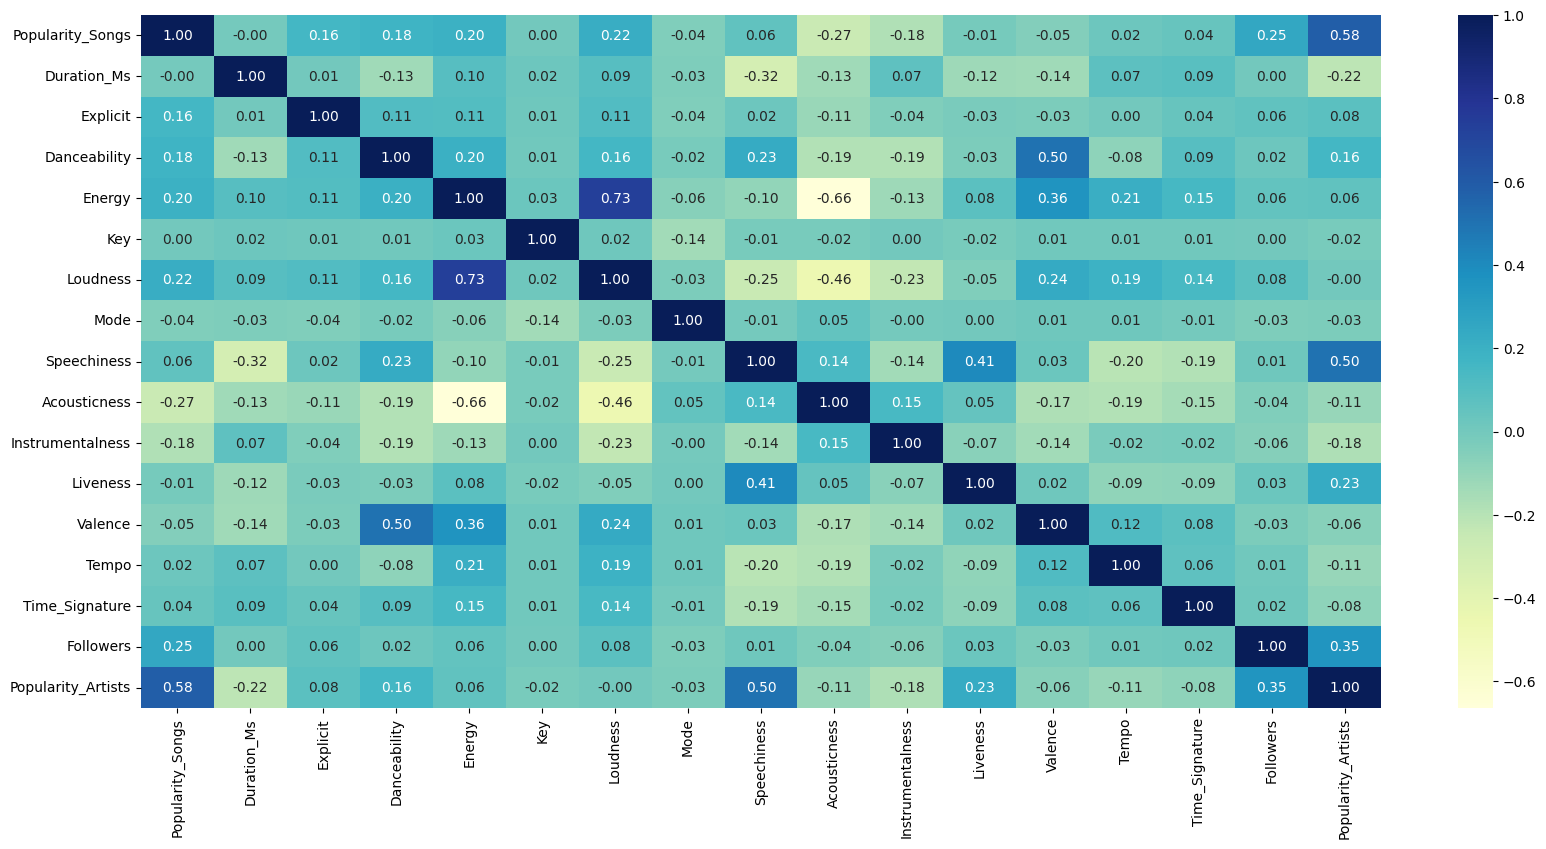

In [102]:
# Creating the heatmap for understang correlation between the variables
plt.figure(figsize = (20, 9))
data = df.corr(numeric_only = True)
sns.heatmap(data, cmap="YlGnBu", annot=True, fmt = '.2f')
plt.show()

In [103]:
# commends:
'''
1> popularity_songs and popularity_Artists have positive correlation .
2> Danceability and valence have positive correlation. 
3> Loudness and Energy have strong positive correlation. 
4> (Speechiness and popularity_songs) and (speechiness and liveness) both are having positive correlation.
5> (followers and popularity_songs) and (followers and popularity_Artists) both are having weak positive correlation. 
6> (Loudness and popularity) and (Loudness and valence) both are having weak positive correlation. 
7> Danceability and speechiness have weak positive correlation.
8> Tempo and energy Having weak positive correlation 
9> Instrumentless and Acousticness have weak positive correlation
''' 

# Important features are :
'''   
popularity_songs,
Popularity_artists 
Danceability, 
Liveness, 
Energy,
Loudness,
Speechiness, 
Valence 
Tempo


'''


'   \npopularity_songs,\nPopularity_artists \nDanceability, \nLiveness, \nEnergy,\nLoudness,\nSpeechiness, \nValence \nTempo\n\n\n'

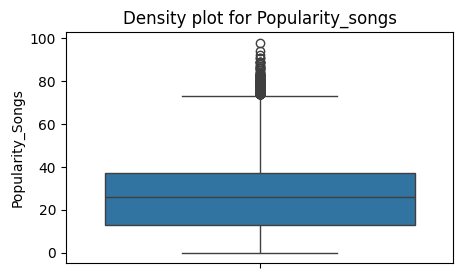

In [104]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.boxplot(df['Popularity_Songs'])
#sns.distplot(df["Annual Income (k$)"], bins = 20, kde = True)
plt.title("Density plot for Popularity_songs")
plt.show()

In [105]:
'As we can see there are upperfence outliers in the data'

'As we can see there are upperfence outliers in the data'

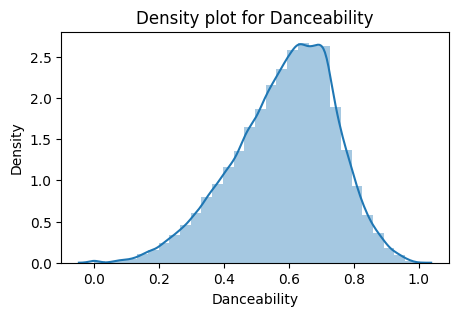

In [106]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Danceability'], bins = 30, kde = True)
#sns.distplot(df["Annual Income (k$)"], bins = 20, kde = True)
plt.title("Density plot for Danceability")
plt.show()

In [107]:
# As we can there is a left tail skewed data normally distributed

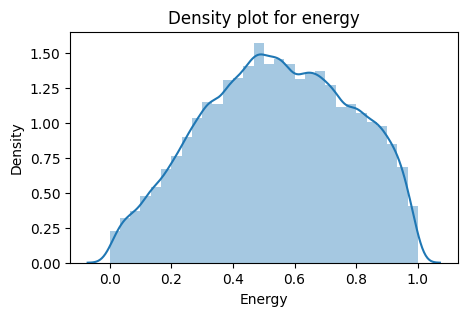

In [108]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Energy'], bins = 30, kde = True)
#sns.distplot(df["Annual Income (k$)"], bins = 20, kde = True)
plt.title("Density plot for energy")
plt.show()

In [109]:
# As we can there is no outliers

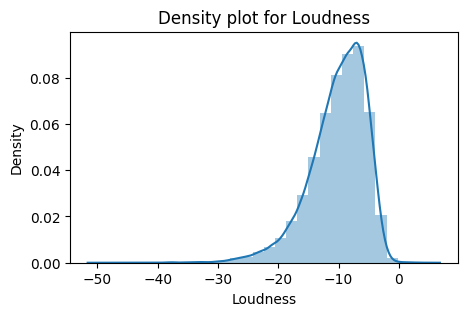

In [110]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Loudness'], bins = 30, kde = True)
#sns.distplot(df["Annual Income (k$)"], bins = 20, kde = True)
plt.title("Density plot for Loudness")
plt.show()

In [111]:
# As we can there lot of outliers in the left tail left skewed data.


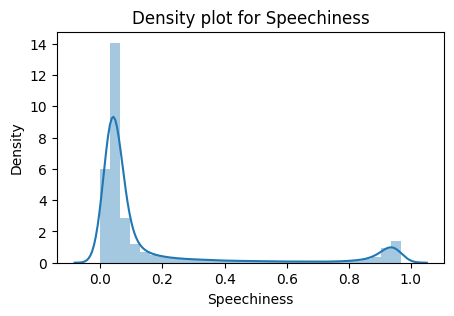

In [112]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Speechiness'], bins = 30, kde = True)
plt.title("Density plot for Speechiness")
plt.show()

In [113]:
'As we can there are huge outliers, long right tail in the data '

'As we can there are huge outliers, long right tail in the data '

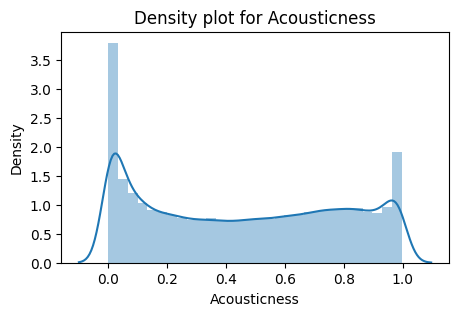

In [114]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Acousticness'], bins = 30, kde = True)
plt.title("Density plot for Acousticness")
plt.show()

In [115]:
# there is no outliers in the data.

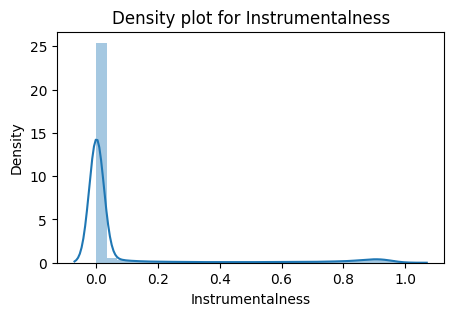

In [116]:
# Identifying the outliers:
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Instrumentalness'], bins = 30, kde = True)
plt.title("Density plot for Instrumentalness")
plt.show()

In [117]:
# As we can see there is more outliers in the long right tail 

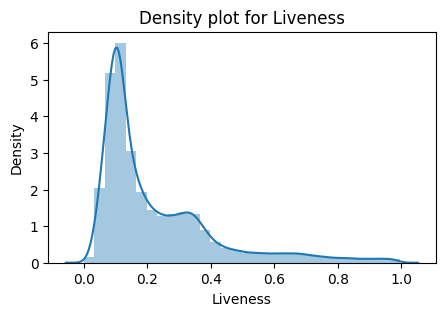

In [118]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Liveness'], bins = 30, kde = True)
plt.title("Density plot for Liveness")
plt.show()

In [119]:
'As we can long right tail outiers in the data'

'As we can long right tail outiers in the data'

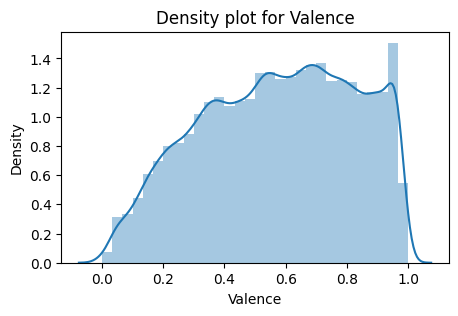

In [120]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Valence'], bins = 30, kde = True)
plt.title("Density plot for Valence")
plt.show()

In [121]:
" As we can see there is no outliers in the data"

' As we can see there is no outliers in the data'

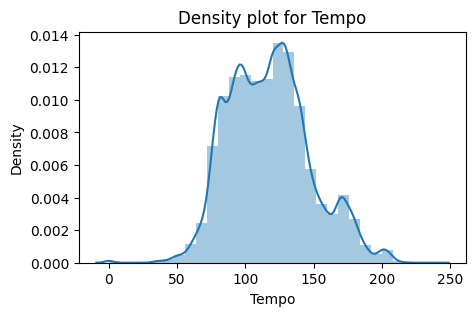

In [122]:
# Identifying outliers :
import seaborn as sns
plt.figure(figsize = (5, 3))
sns.distplot(df['Tempo'], bins = 30, kde = True)
plt.title("Density plot for Tempo")
plt.show()

In [123]:
" As we can slightly outliers both left and right tail" 


' As we can slightly outliers both left and right tail'

In [124]:
# Encoding the catagorical columns:
categorical_col = df.select_dtypes(include = ['object']).columns.to_list() 

# Initializing the Label Encoder 

label_encoder = LabelEncoder() 

# For loop:
for column in categorical_col:
    df[column]=label_encoder.fit_transform(df[column]) 


In [125]:
df.head()

,Popularity_Songs,Duration_Ms,Explicit,Id_Artists,Release_Date,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time_Signature,Followers,Genres,Popularity_Artists
0,0,161427,0,9662,1922-01-01,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,3070,22
1,0,223440,0,9662,1922-01-01,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,3070,22
2,0,208267,0,9662,1922-01-01,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,3070,22
3,0,161933,0,9662,1924-01-01,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,3070,22
4,0,167973,0,9662,1924-01-01,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,3070,22


In [126]:
df.columns

Index(['Popularity_Songs', 'Duration_Ms', 'Explicit', 'Id_Artists',
       'Release_Date', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode',
       'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness',
       'Valence', 'Tempo', 'Time_Signature', 'Followers', 'Genres',
       'Popularity_Artists'],
      dtype='object')

In [127]:
#Feature Selection:
df = df[['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_Ms']]

In [128]:
df.describe()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_Ms
count,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04
mean,0.586853,0.541083,-10.157862,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,2.087320e+05
std,0.155422,0.236304,4.748798,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,1.177526e+05
min,0.000000,0.000020,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.373000e+03
25%,0.488000,0.365000,-12.723000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,1.573330e+05
50%,0.605000,0.542000,-9.397000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,2.040000e+05
75%,0.700000,0.727000,-6.692000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,2.502670e+05
max,0.991000,1.000000,5.376000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,4.800118e+06


In [129]:
# Normalize the data usinf StandardScaler() method : 
 

scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)



In [172]:
# Save the Scalermodel:
with open("C:/guvi/project_4/scaler_model.pkl", "wb") as file:
    pkl.dump(scaler,file)

In [130]:
scaled_df

array([[-0.15347598, -1.51112816, -0.75790895, ...,  0.32128698,
         0.51500516, -0.40173462],
       [-1.02851842, -1.52805562, -1.09862851, ..., -0.57745518,
        -1.2944868 ,  0.12490637],
       [-0.48805103, -1.41802711, -1.12789922, ..., -0.37594348,
        -1.56000306, -0.00394925],
       ...,
       [ 0.14249425, -2.21700341, -3.87787243, ...,  1.27242218,
        -1.62041993, -1.07201656],
       [-0.15991012, -2.14971674, -3.24149759, ..., -0.7588157 ,
        -1.78348586, -0.19941949],
       [-0.17277839, -0.09768491,  0.56580125, ..., -1.46410663,
         0.47552221,  0.4206722 ]], shape=(95837, 10))

In [131]:
# fitting the model:
inertia = [] 
mapping = {} 
K = range(1, 10)

for k in K:
    kmean_model = KMeans(n_clusters = k, random_state = 42)
    kmean_model.fit_transform(scaled_df)
    inertia.append(kmean_model.inertia_)
    mapping[k] = kmean_model.inertia_  


In [132]:
mapping

{1: 958369.9999999993,
 2: 778813.5948784559,
 3: 658335.9621683137,
 4: 593031.0894267311,
 5: 548600.5017752507,
 6: 521625.8732626645,
 7: 494731.167673613,
 8: 470850.5503293442,
 9: 449763.55633500585}

K : 1 ,WCSS : 958369.9999999993
K : 2 ,WCSS : 778813.5948784559
K : 3 ,WCSS : 658335.9621683137
K : 4 ,WCSS : 593031.0894267311
K : 5 ,WCSS : 548600.5017752507
K : 6 ,WCSS : 521625.8732626645
K : 7 ,WCSS : 494731.167673613
K : 8 ,WCSS : 470850.5503293442
K : 9 ,WCSS : 449763.55633500585


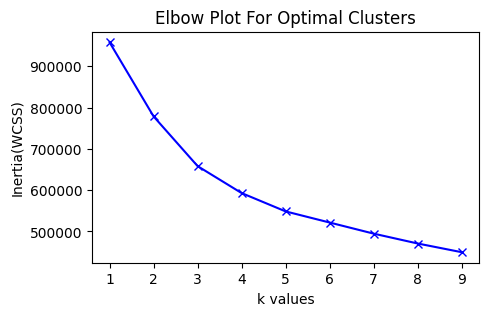

In [133]:
# plotting the elbow plot for optimal clusters for the given data:
for key,val in mapping.items():
    print(f"K : {key} ,WCSS : {val}")
plt.figure(figsize = (5, 3))
plt.plot(K, inertia, 'bx-')
plt.xlabel("k values")
plt.ylabel("Inertia(WCSS)") 
plt.title("Elbow Plot For Optimal Clusters")
plt.show()

In [134]:
"As we can see 3 is the optimal cluster because after three there is no sharp decrease thats why we took optimal cluster is 3 "

kmean_model=KMeans(n_clusters=3, random_state = 42)
labels=kmean_model.fit_predict(scaled_df)
#print(scaled_df)
# Getting the centroids 
centroids = kmean_model.cluster_centers_ 
print('Centroids :\n', centroids)


print(f"\nsilhouette_score:{metrics.silhouette_score(scaled_df,labels)}")

Centroids :
 [[-0.64833254 -0.97494018 -0.64399559 -0.39490289  0.88084544  0.37386832
  -0.23084038 -0.65073924 -0.18589226  0.12530037]
 [ 0.25973562  0.64372722  0.53628308 -0.34050353 -0.60525252 -0.13546034
  -0.13482883  0.37025656  0.24359574  0.1514859 ]
 [ 0.49811802 -0.31528796 -0.67525149  2.40021142  0.38430891 -0.34744971
   1.13306451  0.03934024 -0.56825007 -0.94424044]]

silhouette_score:0.24240141740661852


In [135]:
df['Clusters'] = kmean_model.fit_predict(scaled_df)
df.head()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_Ms,Clusters
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427,0
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440,0
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267,0
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933,0
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973,0


In [136]:
# PCA -principal component Analysis:
pca_model=PCA(n_components=2,svd_solver='full')
data = pca_model.fit_transform(scaled_df)
pca_df=pd.DataFrame(pca_model.fit_transform(scaled_df))
pca_model.explained_variance_ratio_

array([0.27079553, 0.18821441])

In [137]:
pca_df['Clusters'] = df['Clusters']


In [138]:
pca_df

,0,1,Clusters
0,-1.676304,0.291571,0
1,-2.639968,-0.472803,0
2,-2.537328,0.474464,0
3,-0.677418,0.709757,0
4,-1.480657,1.426716,0
...,...,...,...
95832,1.600113,-0.357294,1
95833,1.248094,-1.399771,1
95834,-4.467784,0.402899,0
95835,-4.789999,-0.722302,0


In [139]:
# save pca model 
import pickle as pkl
with open("C:\guvi\project_4\pca.pkl", 'wb') as f:
    pkl.dump(pca_model,f)

In [140]:
# Save the pca_df
pca_df.to_csv('C:/guvi/project_4/pca_df.csv')

In [141]:
labels =labels.astype(float)  
print(labels)

[0. 0. 0. ... 0. 0. 0.]


In [142]:
clusterA = pca_df[pca_df['Clusters'] == 0] 
clusterB = pca_df[pca_df['Clusters'] == 1]
clusterC = pca_df[pca_df['Clusters'] == 2]

In [143]:
clusterA

,0,1,Clusters
0,-1.676304,0.291571,0
1,-2.639968,-0.472803,0
2,-2.537328,0.474464,0
3,-0.677418,0.709757,0
4,-1.480657,1.426716,0
...,...,...,...
95828,-4.931655,-1.552205,0
95831,-0.183286,-0.716436,0
95834,-4.467784,0.402899,0
95835,-4.789999,-0.722302,0


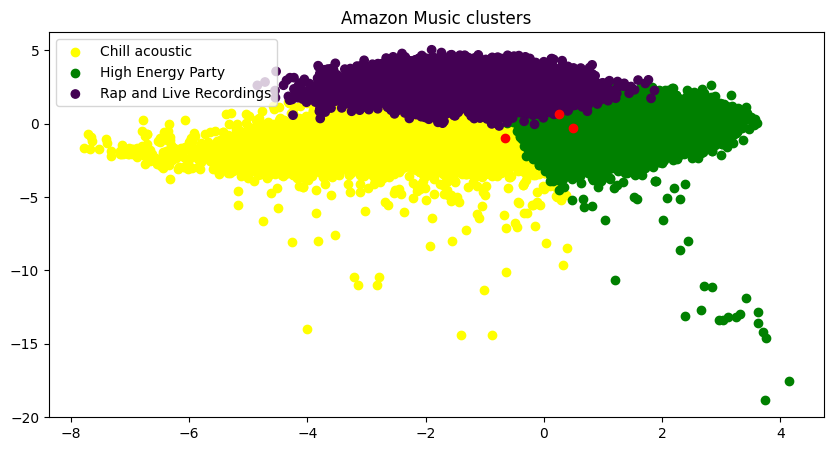

In [144]:
# plot the clusters:
plt.figure(figsize = (10, 5))
plt.scatter(clusterA[0], clusterA[1], c = 'yellow', label = 'Chill acoustic') 
plt.scatter(clusterB[0], clusterB[1], c = 'green', label = 'High Energy Party') 
plt.scatter(clusterC[0], clusterC[1], c = clusterC['Clusters'], label = 'Rap and Live Recordings') 
plt.scatter(centroids[:,0], centroids[:,1], c = 'red') 
plt.title("Amazon Music clusters")
plt.legend(loc = 'upper left')
plt.show()

In [145]:
gt = df.groupby('Clusters')[['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Duration_Ms']].mean()
print(gt)

          Danceability    Energy   Loudness  Speechiness  Acousticness  \
Clusters                                                                 
0             0.486242  0.311018 -13.208988     0.060103      0.749539   
1             0.627309  0.693465  -7.608616     0.075061      0.258713   
2             0.664254  0.466617 -13.364383     0.829908      0.585922   

          Instrumentalness  Liveness   Valence       Tempo    Duration_Ms  
Clusters                                                                   
0                 0.168760  0.182065  0.413047  111.933323  223500.904818  
1                 0.050681  0.199854  0.666324  124.905464  226568.204680  
2                 0.001384  0.435498  0.584036  100.387090   97522.338234  


In [146]:
'''
 INSIGHTS: 
 
Red color bupples are represents cluster centroids for each cluster 
Cluster A = low energy, high acousticness ,low tempo → “Chill acoustic” 
cluster B = high danceabilty,high energy, high valence, high Tembo, low Acousticness ->High Energy Party
Cluster C = high danceability, medium to high energy, high liveness → “Party tracks Rap and Live Recordings”

''' 

'\n INSIGHTS: \n\nRed color bupples are represents cluster centroids for each cluster \nCluster A = low energy, high acousticness ,low tempo → “Chill acoustic” \ncluster B = high danceabilty,high energy, high valence, high Tembo, low Acousticness ->High Energy Party\nCluster C = high danceability, medium to high energy, high liveness → “Party tracks Rap and Live Recordings”\n\n'

In [147]:
# Save the kmeans cluster model:
import pickle as pkl
with open("C:/guvi/project_4/kmeans.pkl", 'wb') as f:
    pkl.dump(kmean_model,f)

In [148]:
# Loading the model:
with open("C:/guvi/project_4/kmeans.pkl", "rb") as f:
    model = pkl.load(f) 
print(model)

KMeans(n_clusters=3, random_state=42)


In [149]:
#saving the dataframe: 
df.to_csv("C:/guvi/project_4/FinalizeData.csv")

In [150]:
#  DBSCAN (for discovering arbitrary-shaped clusters)
''' 
DBSCAN - Density Based Spatial Clustering of Applications with Noise

'''

' \nDBSCAN - Density Based Spatial Clustering of Applications with Noise\n\n'

In [151]:
# DBSCAN :
from sklearn.cluster import DBSCAN
dbmodel = DBSCAN(eps = 2.3, min_samples=5)
pca_df['dblabels'] = dbmodel.fit_predict(scaled_df) 


In [152]:
outliers_df = pca_df[pca_df['dblabels'] == -1]
inliers_df = pca_df[pca_df['dblabels'] != -1]

In [153]:
outliers_df

,0,1,Clusters,dblabels
426,0.885268,-2.471430,1,-1
2098,-1.046169,-5.578362,0,-1
2103,0.028755,-8.106666,0,-1
2853,-2.838721,-2.197465,0,-1
2856,-3.211368,-2.062646,0,-1
...,...,...,...,...
93950,-4.144811,-2.132090,0,-1
93954,-4.319836,-0.887568,0,-1
93965,-0.054293,-0.777031,1,-1
94072,-1.438980,-5.359009,0,-1


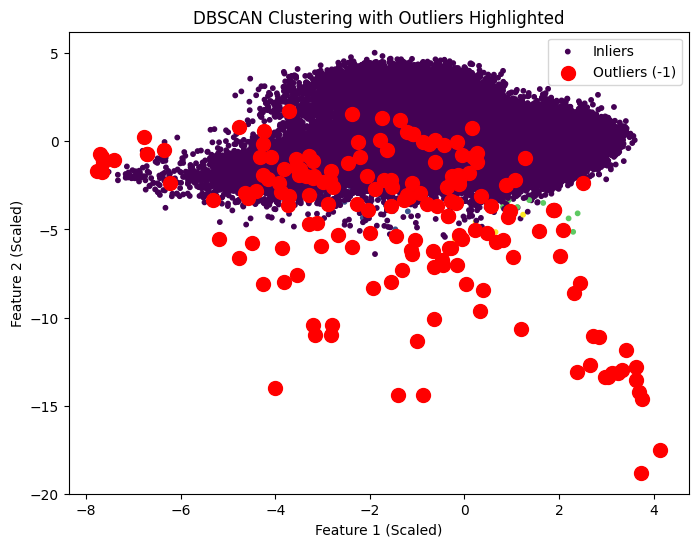

In [154]:
plt.figure(figsize=(8, 6))
plt.scatter(inliers_df[0], inliers_df[1], c=inliers_df['dblabels'], s=10, cmap='viridis', label='Inliers')
plt.scatter(outliers_df[0], outliers_df[1], c='red', marker='o', s=100, label='Outliers (-1)')
plt.title('DBSCAN Clustering with Outliers Highlighted')
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Feature 2 (Scaled)')
plt.legend()
plt.show()

In [155]:
# INSIGHTS:

''' 
here as we can see the above plot shows red color circles are outliers, 
Basically DBSCAN clustering used for indentify the outliers in the data
'''

' \nhere as we can see the above plot shows red color circles are outliers, \nBasically DBSCAN clustering used for indentify the outliers in the data\n'

In [156]:
#  Hierarchical Clustering (Agglomerative)

''' 
Agglomerative algorithm is one of hoerachical clustering algorithm 
it is bottom up apporoch 
group the data based on the proximity

'''

' \nAgglomerative algorithm is one of hoerachical clustering algorithm \nit is bottom up apporoch \ngroup the data based on the proximity\n\n'

In [157]:

from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters=3, linkage = 'ward')
hlabels = clustering.fit_predict(scaled_df) 


In [158]:
'''
linkage = 'ward' 
linkage used to calculated the distance between the clusters
minimizes the variance within clusters when merging them

It calculates the distance between clusters based on how much the sum of squared deviations 
(within-cluster variance) increases upon merging, aiming to create compact, 
roughly equal-sized, spherical clusters 

'''

"\nlinkage = 'ward' \nlinkage used to calculated the distance between the clusters\nminimizes the variance within clusters when merging them\n\nIt calculates the distance between clusters based on how much the sum of squared deviations \n(within-cluster variance) increases upon merging, aiming to create compact, \nroughly equal-sized, spherical clusters \n\n"

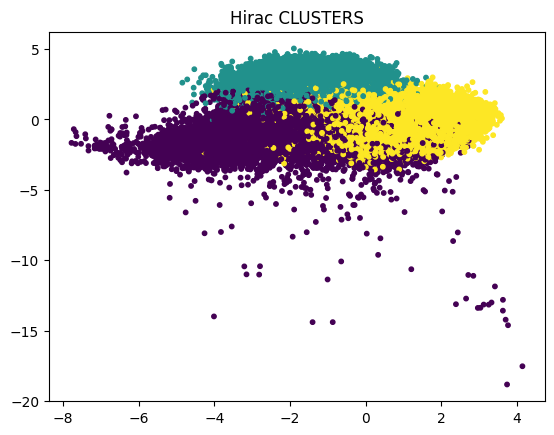

In [159]:
plt.Figure(figsize = (5, 5))
plt.scatter(pca_df[0], pca_df[1], c = hlabels, cmap='viridis', s=10) 
plt.title("Hirac CLUSTERS")
plt.show()

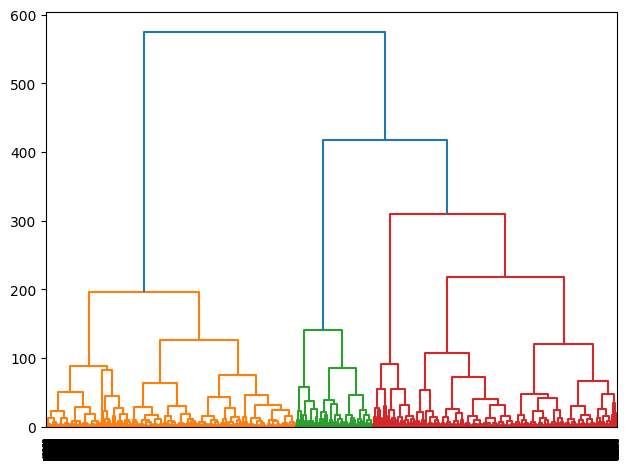

In [160]:
import scipy.cluster.hierarchy as sch 

#create a dendrogram 
plt.Figure(figsize = (21,9))
dendrogram = sch.dendrogram(sch.linkage(data, method = 'ward'))
plt.savefig('dendogram.png', dpi = 300)
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

In [161]:
""" 
Here Root contains all the data points 
optimal number of clusters equal to number if vertical lines 
As we can see above plot says three blue vertical lines 
"""

' \nHere Root contains all the data points \noptimal number of clusters equal to number if vertical lines \nAs we can see above plot says three blue vertical lines \n'

In [162]:
df['Clusters'].dtypes

dtype('int32')

In [163]:
df = pd.read_csv("C:/guvi/project_4/FinalizeData.csv", index_col = 0)
df.head()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Duration_Ms,Clusters
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427,0
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440,0
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267,0
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933,0
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973,0


In [164]:
df['Clusters'] = df['Clusters'].map({2 : 'Party tracks Rap and Live Recordings', 0 : 'Chill_Acoustic', 1 : 'High_Energy_Party'})
df['Clusters'].head(5)

0    Chill_Acoustic
1    Chill_Acoustic
2    Chill_Acoustic
3    Chill_Acoustic
4    Chill_Acoustic
Name: Clusters, dtype: object

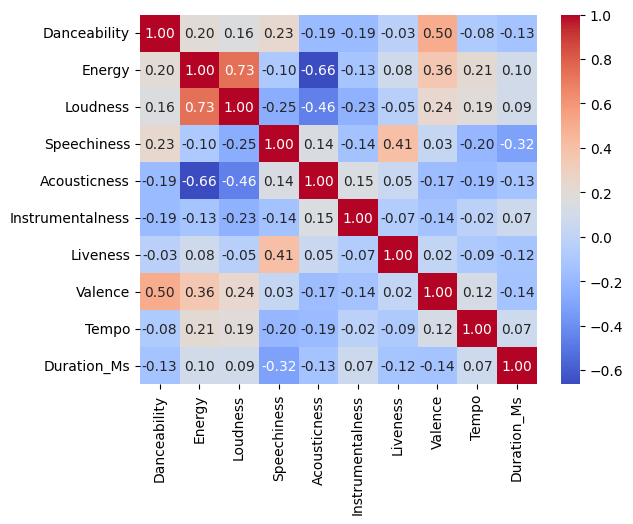

In [165]:
'Heatmaps comparing features across clusters.'
plt.Figure(figsize = (10,5))
data1 = df.corr(numeric_only= True)
sns.heatmap(data1, cmap = "coolwarm", annot = True, fmt = '.2f') 
plt.show()


In [166]:
"Slightly right skewed data and plot is coming like bell hsape curve so that data are normally distributed"

'Slightly right skewed data and plot is coming like bell hsape curve so that data are normally distributed'

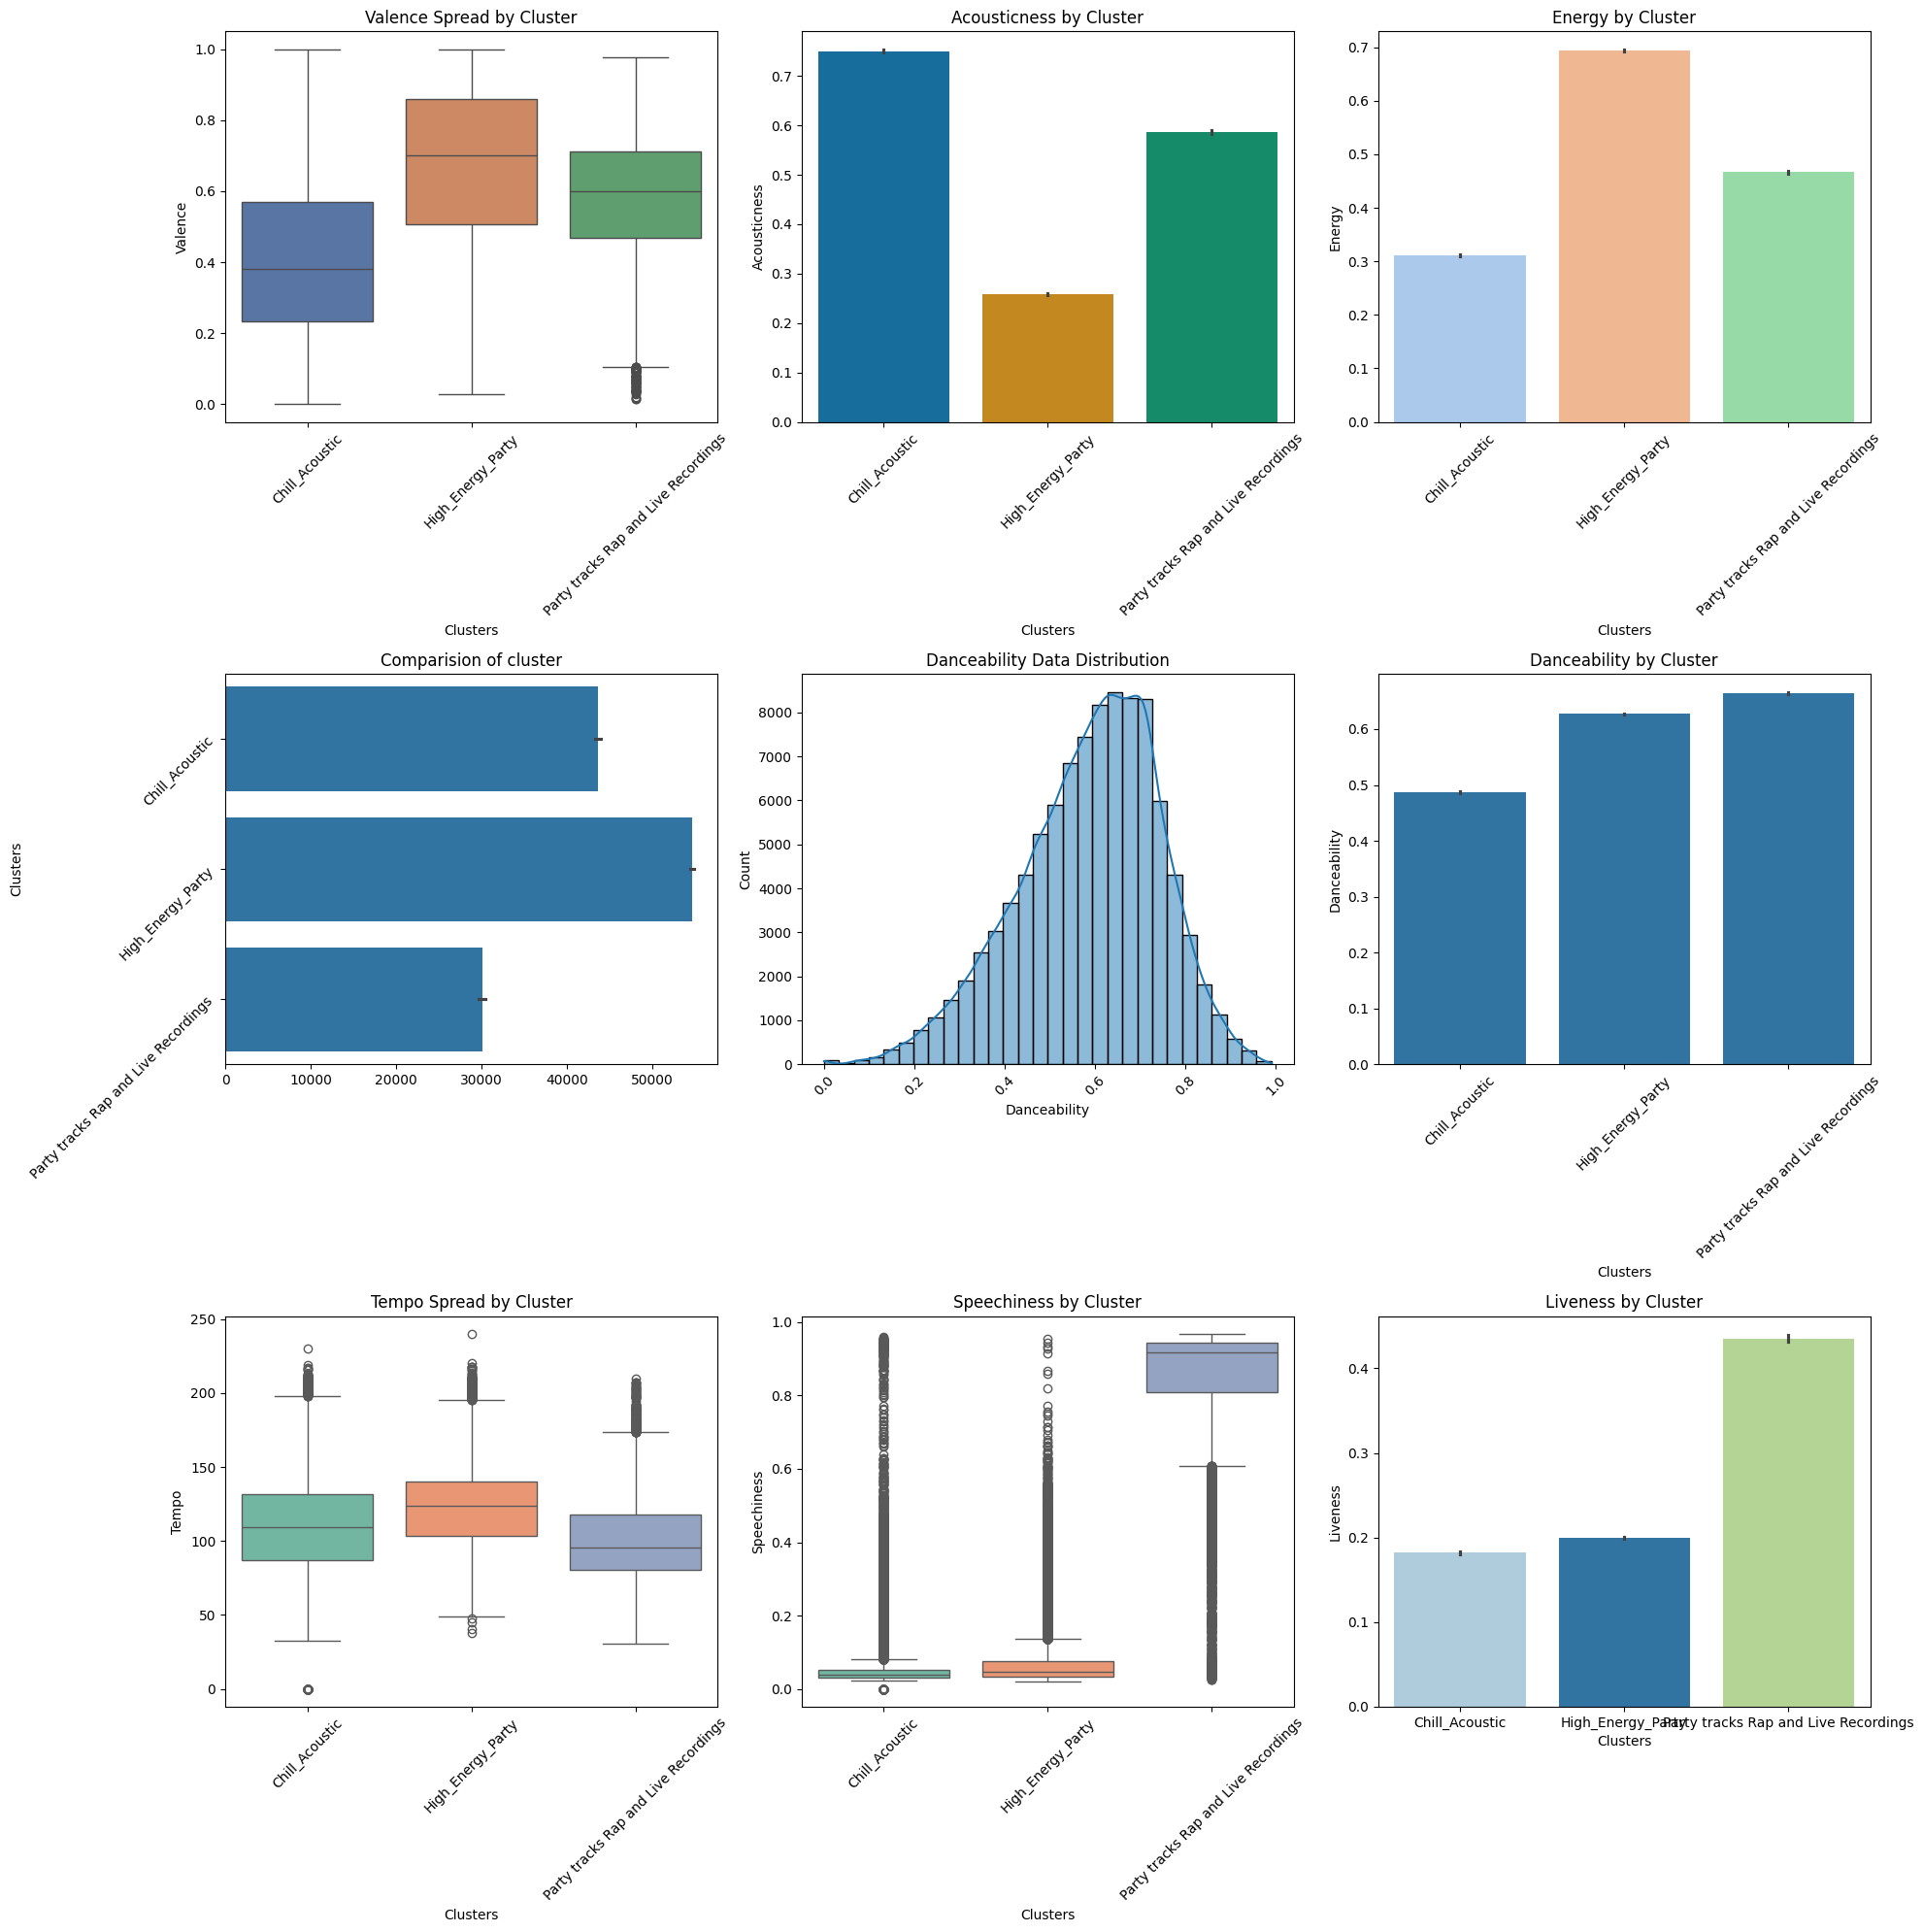

In [167]:
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))

sns.boxplot(x='Clusters', y='Valence', data=df, palette='deep', ax = axs[0,0])
axs[0, 0].set_title('Valence Spread by Cluster') 
axs[0, 0].tick_params(axis='x', labelrotation=45) 

sns.barplot(data = df, x = 'Clusters' ,y ='Acousticness', palette="colorblind", ax = axs[0,1]) 
axs[0, 1].set_title('Acousticness by Cluster') 
axs[0, 1].tick_params(axis='x', labelrotation=45) 

sns.barplot(data = df, x = 'Clusters' ,y ='Energy', palette="pastel", ax = axs[0, 2]) 
axs[0, 2].set_title('Energy by Cluster') 
axs[0, 2].tick_params(axis='x', labelrotation=45) 

sns.barplot(df['Clusters'], ax = axs[1,0])
axs[1, 0].set_title('Comparision of cluster')
axs[1, 0].tick_params(axis='y', labelrotation=45)  

sns.histplot(df['Danceability'], bins = 30, kde = True, ax = axs[1,1]) 
axs[1, 1].set_title('Danceability Data Distribution') 
axs[1, 1].tick_params(axis='x', labelrotation=45) 

sns.barplot(data = df, x = 'Clusters' ,y ='Danceability', ax = axs[1,2]) 
axs[1, 2].set_title('Danceability by Cluster') 
axs[1, 2].tick_params(axis='x', labelrotation=45) 
 

sns.boxplot(x='Clusters', y='Tempo', data=df, palette='Set2', ax = axs[2,0])
axs[2, 0].set_title('Tempo Spread by Cluster')
axs[2, 0].tick_params(axis='x', labelrotation=45) 

sns.boxplot(x='Clusters', y='Speechiness', data=df, palette='Set2',ax = axs[2,1])
axs[2, 1].set_title('Speechiness by Cluster') 
axs[2, 1].tick_params(axis='x', labelrotation=45)

sns.barplot(data = df, x = 'Clusters' ,y ='Liveness', palette="Paired", ax = axs[2,2]) 
axs[2, 2].set_title('Liveness by Cluster')
 
# Adjust layout to prevent overlapping titles
plt.tight_layout()
plt.show()

In [168]:
import sklearn
print(sklearn.__version__)


1.8.0
